# IY021 - Raw SVM vs catch22+SVM: Dual-Channel NEW Experimental Data

This notebook mirrors `IY021_catch22_svm_exp_data_dual.ipynb`, but uses the refactored `_NEW` paired experimental dataset:

`EXP-25-IY008/4_transformed_exp_time_series_NEW`

The `_NEW` data contains many TF groups rather than the old six glucose/TF classes. The notebook discovers paired mCherry/GFP files, normalises TF labels, selects the largest classes with enough paired cells, balances classes, then compares:

- raw concatenated dual-channel time series + RBF SVM;
- per-channel catch22 features + RBF SVM.


In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pycatch22
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm


def find_project_root(start=None):
    """Find the repository root from either the repo or experiment directory."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "experiments").exists():
            return candidate
    raise RuntimeError("Could not find stochastic_simulations project root.")


PROJECT_ROOT = find_project_root()
EXP_DIR = PROJECT_ROOT / "experiments"
IY021_DIR = EXP_DIR / "EXP-26-IY021"
DATA_DIR = EXP_DIR / "EXP-25-IY008" / "4_transformed_exp_time_series_NEW"
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR.resolve()))

RANDOM_STATE = 42
META_COLS = ["id", "group", "experiment"]
MIN_CELLS_PER_CLASS = 50
MAX_CLASSES = 12

# set random seed and plot styles
np.random.seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir exists: {DATA_DIR.exists()} -> {DATA_DIR}")

Project root: /home/ianyang/stochastic_simulations
Data dir exists: True -> /home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series_NEW


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Discover Paired NEW Data and Assign TF Labels

In [2]:
def normalise_tf_name(group_name):
    """Remove channel prefixes and normalise TF names for cross-experiment grouping."""
    return re.sub(r"^ch\d+_", "", str(group_name)).upper()


def count_rows(csv_path):
    """Count data rows in a CSV without loading the whole file."""
    with open(csv_path) as handle:
        return sum(1 for _ in handle) - 1


def discover_paired_files(data_dir):
    """Find file stems that have both mCherry and GFP time-series CSVs."""
    if not data_dir.exists():
        raise FileNotFoundError(f"Missing data directory: {data_dir}")

    gfp = {p.stem.replace("_GFP_time_series", ""): p for p in data_dir.glob("*_GFP_time_series.csv")}
    mcherry = {p.stem.replace("_mCherry_time_series", ""): p for p in data_dir.glob("*_mCherry_time_series.csv")}
    paired_keys = sorted(set(gfp) & set(mcherry))

    rows = []
    for key in paired_keys:
        experiment = key.split("_group_")[0]
        group = key.split("_group_", 1)[1]
        rows.append({
            "key": key,
            "experiment": experiment,
            "group": group,
            "tf": normalise_tf_name(group),
            "mcherry_path": mcherry[key],
            "gfp_path": gfp[key],
            "n_rows": count_rows(mcherry[key]),
        })
    return pd.DataFrame(rows)


# use the discover_paired_files function to find and filter paired files, then count classes and select those with enough paired cells
pair_table = discover_paired_files(DATA_DIR)
class_counts = (
    pair_table.groupby("tf", as_index=False)["n_rows"]
    .sum()
    .rename(columns={"n_rows": "paired_cells"})
    .sort_values("paired_cells", ascending=False)
)
selected_classes = (
    class_counts.loc[class_counts["paired_cells"] >= MIN_CELLS_PER_CLASS, "tf"] # a class is only selected if it has at least MIN_CELLS_PER_CLASS paired cells
    .head(MAX_CLASSES) # limit to MAX_CLASSES classes with the most paired cells
    .tolist()
)

print(f"Paired mCherry/GFP file pairs: {len(pair_table)}")
print(f"Classes with >= {MIN_CELLS_PER_CLASS} paired cells: {(class_counts['paired_cells'] >= MIN_CELLS_PER_CLASS).sum()}")
print(f"Selected classes ({len(selected_classes)}): {selected_classes}")
display(class_counts.head(25))

Paired mCherry/GFP file pairs: 163
Classes with >= 50 paired cells: 45
Selected classes (12): ['OPI1', 'MSN2', 'YOX1', 'TEA1', 'ROX1', 'SOK2', 'CUP9', 'SPT15', 'CBF1', 'STB5', 'CIN5', 'RSC3']


,tf,paired_cells
52,OPI1,223
49,MSN2,206
95,YOX1,177
84,TEA1,158
64,ROX1,139
69,SOK2,132
14,CUP9,125
70,SPT15,121
9,CBF1,114
75,STB5,111


In [3]:
def load_selected_pairs(pair_table, selected_classes):
    """Load paired mCherry/GFP traces for selected TF classes."""
    m_arrays, g_arrays, metadata_rows = [], [], []
    selected_table = pair_table[pair_table["tf"].isin(selected_classes)].copy()

    for _, row in selected_table.iterrows():
        df_m = pd.read_csv(row["mcherry_path"])
        df_g = pd.read_csv(row["gfp_path"])
        time_cols_m = [c for c in df_m.columns if c not in META_COLS]
        time_cols_g = [c for c in df_g.columns if c not in META_COLS]
        # Keep only cells observed in both channels so paired rows stay aligned.
        common_ids = sorted(set(df_m["id"]) & set(df_g["id"]))

        df_m = df_m[df_m["id"].isin(common_ids)].set_index("id").loc[common_ids]
        df_g = df_g[df_g["id"].isin(common_ids)].set_index("id").loc[common_ids]

        m_arrays.append(df_m[time_cols_m].to_numpy(float))
        g_arrays.append(df_g[time_cols_g].to_numpy(float))
        for cell_id in common_ids:
            metadata_rows.append({
                "cell_id": cell_id,
                "class_name": row["tf"],
                "tf": row["tf"],
                "group": row["group"],
                "experiment": row["experiment"],
                "source_key": row["key"],
            })

        print(f"{row['tf']:8s} {row['experiment']:>5s} {row['group']:<18s}: {len(common_ids):4d} paired cells")

    # we extract the min number of timepoints across both arrays, as this will determine the max number of timepoints we can use for all cells without padding
    # Truncate each channel to its own common length before stacking experiments.
    min_tp_m = min(arr.shape[1] for arr in m_arrays)
    min_tp_g = min(arr.shape[1] for arr in g_arrays)
    X_m = np.vstack([arr[:, :min_tp_m] for arr in m_arrays])
    X_g = np.vstack([arr[:, :min_tp_g] for arr in g_arrays])
    metadata = pd.DataFrame(metadata_rows)
    class_to_label = {name: idx for idx, name in enumerate(selected_classes)}
    metadata["label"] = metadata["class_name"].map(class_to_label).astype(int)
    return X_m, X_g, metadata, min_tp_m, min_tp_g, class_to_label


X_m_raw, X_g_raw, metadata_raw, min_tp_m, min_tp_g, class_to_label = load_selected_pairs(pair_table, selected_classes)
label_names = {idx: name for name, idx in class_to_label.items()}
class_names = [label_names[i] for i in sorted(label_names)]

print(f"mCherry matrix: {X_m_raw.shape} ({min_tp_m} timepoints)")
print(f"GFP matrix    : {X_g_raw.shape} ({min_tp_g} timepoints)")
display(metadata_raw["class_name"].value_counts().rename_axis("class_name").reset_index(name="n"))

YOX1      2801 ch10_YOX1         :   74 paired cells
CUP9      2801 ch11_CUP9         :   81 paired cells
CIN5      2801 ch12_CIN5         :   18 paired cells
CBF1      2801 ch15_CBF1         :   44 paired cells


OPI1      2801 ch8_OPI1          :   48 paired cells
CIN5      2858 Cin5              :   28 paired cells
CUP9      2858 Cup9              :    8 paired cells
OPI1      2858 Opi1              :   70 paired cells
YOX1      2858 Yox1              :  103 paired cells
MSN2      4052 MSN2              :   29 paired cells
ROX1      4052 Rox1              :   60 paired cells
SPT15     4052 Spt15             :   52 paired cells
MSN2      4103 MSN2              :   51 paired cells
RSC3      4103 Rsc3              :  106 paired cells
CBF1      4104 Cbf1              :   70 paired cells
MSN2      4104 MSN2              :    4 paired cells
ROX1      4104 Rox1              :   79 paired cells
SPT15     4104 Spt15             :   69 paired cells
CIN5      4105 Cin5              :   62 paired cells
CUP9      4105 Cup9              :   36 paired cells
MSN2      4105 MSN2              :  122 paired cells
OPI1      4105 Opi1              :  105 paired cells
SOK2      4105 Sok2              :  132 paired

,class_name,n
0,OPI1,223
1,MSN2,206
2,YOX1,177
3,TEA1,158
4,ROX1,139
5,SOK2,132
6,CUP9,125
7,SPT15,121
8,CBF1,114
9,STB5,111


## 2. Preprocessing: NaN Fill, Balancing, and Train/Test Split

In [4]:
def fill_nans(X, random_state=42):
    """Impute missing cell-trace values with a deterministic IterativeImputer."""
    X_arr = np.asarray(X, dtype=float)
    original_shape = X_arr.shape
    X_filled = np.atleast_2d(X_arr).copy()
    if not np.isnan(X_filled).any():
        return X_filled.reshape(original_shape)

    # IterativeImputer cannot infer a timepoint if every cell is missing there.
    all_nan_cols = np.isnan(X_filled).all(axis=0)
    if all_nan_cols.any():
        finite_values = X_filled[np.isfinite(X_filled)]
        fill_value = float(np.nanmean(finite_values)) if finite_values.size else 0.0
        X_filled[:, all_nan_cols] = fill_value

    imputer = IterativeImputer(
        max_iter=10,
        tol=1e-3,
        initial_strategy="mean", # use "median" if there are outliers, but we could just default to mean
        random_state=random_state,
    )
    X_imputed = imputer.fit_transform(X_filled)

    # In case there are still NaNs (e.g. if all values were NaN), fill them with column medians or global median as a fallback.
    if np.isnan(X_imputed).any():
        col_medians = np.nanmedian(X_imputed, axis=0)
        global_median = float(np.nanmedian(X_imputed)) if np.isfinite(X_imputed).any() else 0.0
        col_medians = np.where(np.isfinite(col_medians), col_medians, global_median)
        nan_mask = np.isnan(X_imputed)
        X_imputed[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

    return X_imputed.reshape(original_shape)

def balance_by_label(X_m, X_g, metadata, random_state=42):
    """Subsample every class to the minority class size."""
    rng = np.random.default_rng(random_state)
    labels = metadata["label"].to_numpy()
    # number of cells in the smallest class, and we will subsample all classes to this size to ensure balance
    min_count = min(np.sum(labels == label) for label in sorted(np.unique(labels)))
    keep_idx = np.concatenate([
        rng.choice(np.where(labels == label)[0], size=min_count, replace=False)
        for label in sorted(np.unique(labels))
    ])
    # Sort after random sampling to keep matrices and metadata in the same order.
    keep_idx = np.sort(keep_idx)
    return X_m[keep_idx], X_g[keep_idx], metadata.iloc[keep_idx].reset_index(drop=True)


# Impute channels separately so the two fluorescence traces keep their own structure.
X_m_clean = fill_nans(X_m_raw)
X_g_clean = fill_nans(X_g_raw)
X_m_bal, X_g_bal, metadata = balance_by_label(X_m_clean, X_g_clean, metadata_raw, RANDOM_STATE)
y = metadata["label"].to_numpy()
# Concatenate timepoints only after balancing so raw SVM features remain paired by cell.
X_raw = np.concatenate([X_m_bal, X_g_bal], axis=1)

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X_raw,
    y,
    metadata,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"NaNs after fill: mCherry={np.isnan(X_m_clean).sum()}, GFP={np.isnan(X_g_clean).sum()}")
print(f"Balanced cells: {len(metadata)}")
print(f"Combined feature matrix: {X_raw.shape} ({min_tp_m} mCherry + {min_tp_g} GFP timepoints)")
print(f"Train/test: {len(y_train)} / {len(y_test)}")
print(f"Train counts: {np.bincount(y_train)}")
print(f"Test counts : {np.bincount(y_test)}")
display(metadata["class_name"].value_counts().sort_index().rename_axis("class_name").reset_index(name="balanced_n"))

NaNs after fill: mCherry=0, GFP=0
Balanced cells: 1272
Combined feature matrix: (1272, 36) (18 mCherry + 18 GFP timepoints)
Train/test: 1017 / 255
Train counts: [85 85 85 84 85 85 84 84 85 85 85 85]
Test counts : [21 21 21 22 21 21 22 22 21 21 21 21]


,class_name,balanced_n
0,CBF1,106
1,CIN5,106
2,CUP9,106
3,MSN2,106
4,OPI1,106
5,ROX1,106
6,RSC3,106
7,SOK2,106
8,SPT15,106
9,STB5,106


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_catch22_svm_dual_NEW_trace_overview.png


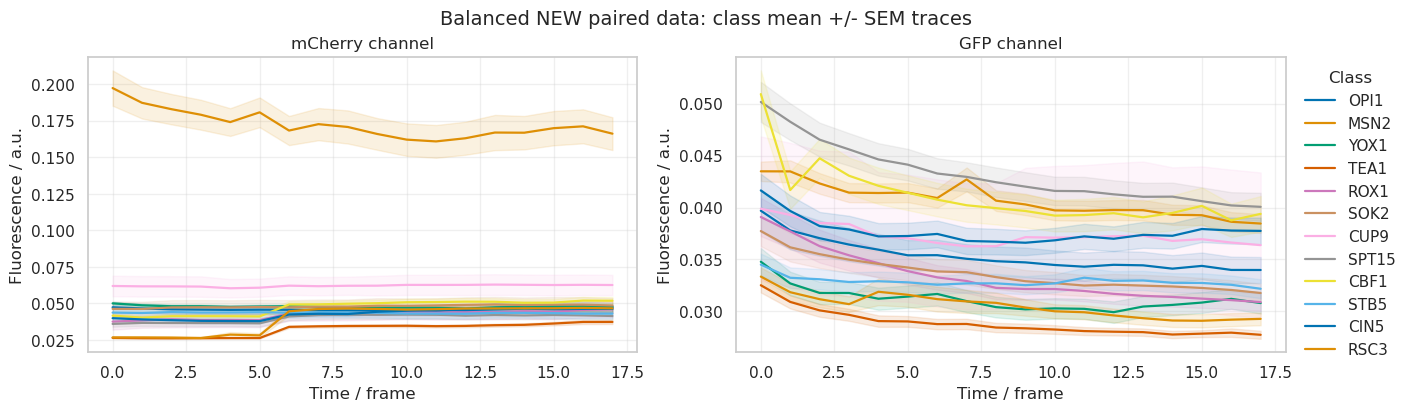

In [5]:
# Visual check of class-average traces after balancing.
palette = sns.color_palette("colorblind", n_colors=len(class_names))
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=False, sharey=False, constrained_layout=True)

for label, class_name in enumerate(class_names):
    mask = y == label
    m_mean = X_m_bal[mask].mean(axis=0)
    m_sem = X_m_bal[mask].std(axis=0, ddof=1) / np.sqrt(mask.sum())
    g_mean = X_g_bal[mask].mean(axis=0)
    g_sem = X_g_bal[mask].std(axis=0, ddof=1) / np.sqrt(mask.sum())
    color = palette[label]

    axes[0].plot(np.arange(min_tp_m), m_mean, label=class_name, color=color, linewidth=1.6)
    # we use fill_between to show the SEM as a shaded area around the mean trace, with some transparency (alpha=0.12)
    axes[0].fill_between(np.arange(min_tp_m), m_mean - m_sem, m_mean + m_sem, color=color, alpha=0.12)
    axes[1].plot(np.arange(min_tp_g), g_mean, label=class_name, color=color, linewidth=1.6)
    axes[1].fill_between(np.arange(min_tp_g), g_mean - g_sem, g_mean + g_sem, color=color, alpha=0.12)

axes[0].set_title("mCherry channel")
axes[1].set_title("GFP channel")
for ax in axes:
    ax.set_xlabel("Time / frame")
    ax.set_ylabel("Fluorescence / a.u.")
    ax.grid(alpha=0.3)

axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False, title="Class")
fig.suptitle("Balanced NEW paired data: class mean +/- SEM traces", fontsize=14)
overview_path = IY021_DIR / "IY021_catch22_svm_dual_NEW_trace_overview.png"
fig.savefig(overview_path, dpi=300, bbox_inches="tight")
print(f"Saved: {overview_path}")
plt.show()

## 3. Raw SVM (RBF) - Concatenated Dual-Channel Time Series

In [6]:
print("=== Raw SVM (RBF) ===")
raw_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
])
raw_pipe.fit(X_train, y_train)
y_pred_raw = raw_pipe.predict(X_test)
raw_acc = accuracy_score(y_test, y_pred_raw)

print(f"Raw SVM accuracy: {raw_acc:.4f}")
print()
print(classification_report(y_test, y_pred_raw, target_names=class_names))

=== Raw SVM (RBF) ===
Raw SVM accuracy: 0.3137

              precision    recall  f1-score   support

        OPI1       0.13      0.19      0.16        21
        MSN2       0.73      0.90      0.81        21
        YOX1       0.00      0.00      0.00        21
        TEA1       0.20      0.77      0.32        22
        ROX1       0.00      0.00      0.00        21
        SOK2       0.12      0.19      0.15        21
        CUP9       0.53      0.73      0.62        22
       SPT15       0.38      0.41      0.39        22
        CBF1       0.40      0.29      0.33        21
        STB5       0.00      0.00      0.00        21
        CIN5       0.50      0.05      0.09        21
        RSC3       0.33      0.19      0.24        21

    accuracy                           0.31       255
   macro avg       0.28      0.31      0.26       255
weighted avg       0.28      0.31      0.26       255



/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

## 4. catch22 + SVM (RBF)

catch22 features are extracted separately for mCherry and GFP, then concatenated into a 44-feature dual-channel representation.


In [7]:
def extract_catch22(X, desc=""):
    """Extract the 22 canonical catch22 features for each row of X."""
    rows = []
    for ts in tqdm(X, desc=desc, leave=False):
        out = pycatch22.catch22_all(ts.tolist())
        rows.append(dict(zip(out["names"], out["values"])))

    features = pd.DataFrame(rows)
    features = features.replace([np.inf, -np.inf], np.nan)
    return features


def fit_fill_feature_frame(train_df, test_df):
    """Fill non-finite feature values using medians estimated on the train split."""
    train_df = train_df.copy()
    test_df = test_df.copy()
    medians = train_df.median()
    train_df = train_df.fillna(medians).fillna(0.0)
    test_df = test_df.fillna(medians).fillna(0.0)
    return train_df, test_df


# Recover channel-specific matrices from the concatenated raw feature matrix.
X_train_m = X_train[:, :min_tp_m]
X_train_g = X_train[:, min_tp_m:]
X_test_m = X_test[:, :min_tp_m]
X_test_g = X_test[:, min_tp_m:]

print("Extracting catch22 features - mCherry train...")
c22_train_m = extract_catch22(X_train_m, desc="mCherry train")
print("Extracting catch22 features - GFP train...")
c22_train_g = extract_catch22(X_train_g, desc="GFP train")
print("Extracting catch22 features - mCherry test...")
c22_test_m = extract_catch22(X_test_m, desc="mCherry test")
print("Extracting catch22 features - GFP test...")
c22_test_g = extract_catch22(X_test_g, desc="GFP test")

c22_train_m, c22_test_m = fit_fill_feature_frame(c22_train_m, c22_test_m)
c22_train_g, c22_test_g = fit_fill_feature_frame(c22_train_g, c22_test_g)

c22_train_m.columns = [f"mCherry_{c}" for c in c22_train_m.columns]
c22_test_m.columns = [f"mCherry_{c}" for c in c22_test_m.columns]
c22_train_g.columns = [f"GFP_{c}" for c in c22_train_g.columns]
c22_test_g.columns = [f"GFP_{c}" for c in c22_test_g.columns]

X_train_c22 = pd.concat([c22_train_m.reset_index(drop=True), c22_train_g.reset_index(drop=True)], axis=1)
X_test_c22 = pd.concat([c22_test_m.reset_index(drop=True), c22_test_g.reset_index(drop=True)], axis=1)

print(f"catch22 feature matrix: {X_train_c22.shape[1]} features (22 mCherry + 22 GFP)")

print("\n=== catch22 + SVM (RBF) ===")
c22_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)),
])
c22_pipe.fit(X_train_c22, y_train)
y_pred_c22 = c22_pipe.predict(X_test_c22)
c22_acc = accuracy_score(y_test, y_pred_c22)

print(f"catch22 + SVM accuracy: {c22_acc:.4f}")
print()
print(classification_report(y_test, y_pred_c22, target_names=class_names))

Extracting catch22 features - mCherry train...


Extracting catch22 features - GFP train...


Extracting catch22 features - mCherry test...


Extracting catch22 features - GFP test...


catch22 feature matrix: 44 features (22 mCherry + 22 GFP)

=== catch22 + SVM (RBF) ===
catch22 + SVM accuracy: 0.3373

              precision    recall  f1-score   support

        OPI1       0.17      0.14      0.15        21
        MSN2       0.21      0.19      0.20        21
        YOX1       0.31      0.43      0.36        21
        TEA1       0.43      0.59      0.50        22
        ROX1       0.47      0.33      0.39        21
        SOK2       0.21      0.19      0.20        21
        CUP9       0.48      0.45      0.47        22
       SPT15       0.38      0.27      0.32        22
        CBF1       0.11      0.05      0.07        21
        STB5       0.31      0.38      0.34        21
        CIN5       0.23      0.24      0.23        21
        RSC3       0.52      0.76      0.62        21

    accuracy                           0.34       255
   macro avg       0.32      0.34      0.32       255
weighted avg       0.32      0.34      0.32       255



## 5. Results Comparison

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_catch22_svm_dual_NEW_results.csv


,model,accuracy
0,catch22 + SVM (RBF),0.337255
1,Raw SVM (RBF),0.313725


Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_dual_channel_svm_vs_catch22_NEW.png


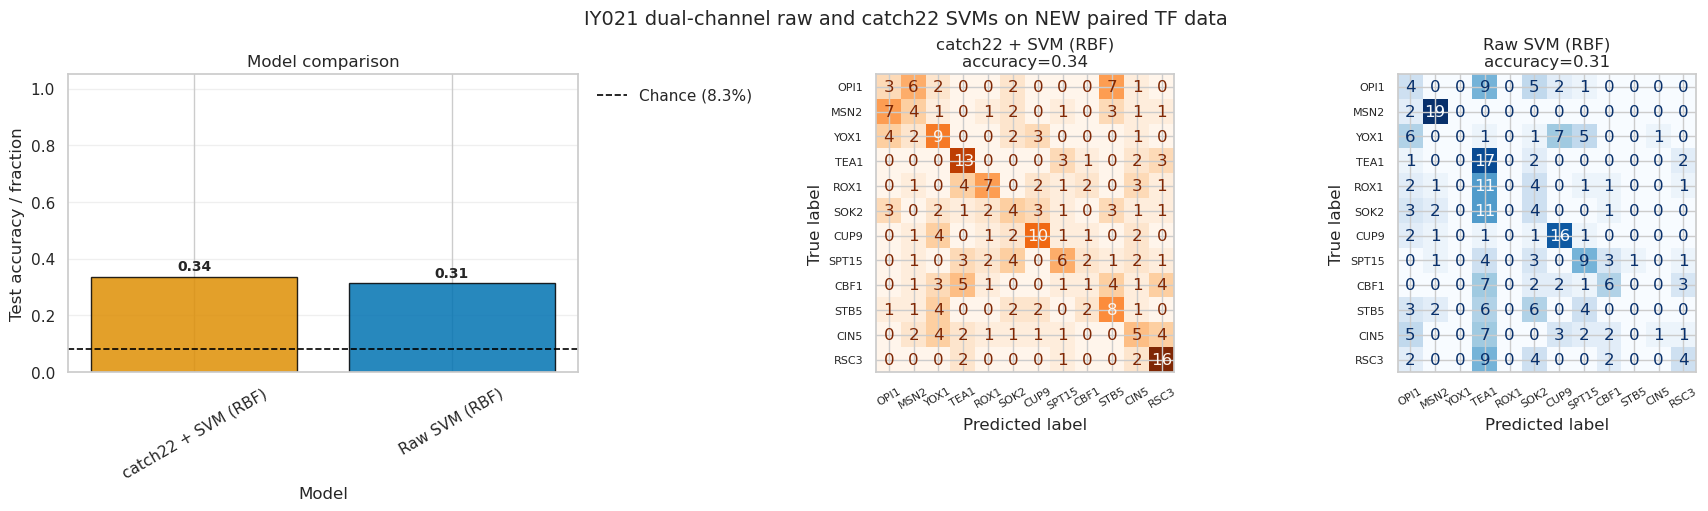


=== Summary ===
  Chance level        : 0.0833
  catch22 + SVM (RBF)   : 0.3373
  Raw SVM (RBF)         : 0.3137
  Winner: catch22 + SVM (RBF) (+0.0235)


In [8]:
chance = 1 / len(class_names)
summary_df = pd.DataFrame([
    {"model": "Raw SVM (RBF)", "accuracy": raw_acc},
    {"model": "catch22 + SVM (RBF)", "accuracy": c22_acc},
]).sort_values("accuracy", ascending=False).reset_index(drop=True)

results_path = IY021_DIR / "IY021_catch22_svm_dual_NEW_results.csv"
summary_df.to_csv(results_path, index=False)
print(f"Saved: {results_path}")
display(summary_df)

predictions = {
    "Raw SVM (RBF)": y_pred_raw,
    "catch22 + SVM (RBF)": y_pred_c22,
}
cmaps = {
    "Raw SVM (RBF)": "Blues",
    "catch22 + SVM (RBF)": "Oranges",
}
colors = {
    "Raw SVM (RBF)": sns.color_palette("colorblind")[0],
    "catch22 + SVM (RBF)": sns.color_palette("colorblind")[1],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
bars = axes[0].bar(
    summary_df["model"],
    summary_df["accuracy"],
    color=[colors[m] for m in summary_df["model"]],
    alpha=0.85,
    edgecolor="black",
)
axes[0].axhline(chance, color="black", linestyle="--", linewidth=1.2, label=f"Chance ({chance:.1%})")
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Test accuracy / fraction")
axes[0].set_title("Model comparison")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
axes[0].grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, summary_df["accuracy"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

for ax, (_, row) in zip(axes[1:], summary_df.iterrows()):
    model_name = row["model"]
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[model_name],
        display_labels=class_names,
        ax=ax,
        colorbar=False,
        cmap=cmaps[model_name],
        xticks_rotation=30,
    )
    ax.set_title(f"{model_name}\naccuracy={row['accuracy']:.2f}")
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("IY021 dual-channel raw and catch22 SVMs on NEW paired TF data", fontsize=14)
fig_path = IY021_DIR / "IY021_dual_channel_svm_vs_catch22_NEW.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

print("\n=== Summary ===")
print(f"  Chance level        : {chance:.4f}")
for _, row in summary_df.iterrows():
    print(f"  {row['model']:<22s}: {row['accuracy']:.4f}")
print(f"  Winner: {summary_df.iloc[0]['model']} (+{summary_df.iloc[0]['accuracy'] - summary_df.iloc[-1]['accuracy']:.4f})")